In [9]:
import numpy as np
import matplotlib.pyplot as plt
import verde as vd
import harmonica as hm
import boule as bl
import choclo
from numpy.linalg import inv

In [10]:
I_source = 45
D_source = 45
m_source = 1e9

m_jr = - m_source * np.sin(I_source)
m_jtheta = - m_source * np.cos(I_source) * np.cos(D_source)
m_jphi = m_source * np.cos(I_source) * np.cos(D_source)

In [11]:
CM = choclo.constants.VACUUM_MAGNETIC_PERMEABILITY / 4 / np.pi
ellipsoid = bl.WGS84
coordinates = vd.grid_coordinates(
    region=(-3, 4, -2, 3),
    shape=(40, 40),
    extra_coords=ellipsoid.mean_radius,
)
longitude, sph_latitude, radius_obs = tuple(c.ravel() for c in coordinates)

In [12]:
colatitude_obs = np.pi/2 - np.deg2rad(sph_latitude)
longitude_obs = np.deg2rad(longitude)

In [13]:
longitude_source_deg, latitude_source_deg = 0.30, 0.30
longitude_source = np.deg2rad(longitude_source_deg)
colatitude_source = np.pi/2 - np.deg2rad(latitude_source_deg)
radius_source = ellipsoid.mean_radius - 5e4

source_coordinates = (longitude_source_deg, latitude_source_deg, radius_source)

In [14]:
n = len(longitude)
diff_long_obs_longe_source = np.empty(n)

for i in range(n):
    diff_long_obs_longe_source[i] = longitude_obs[i] - longitude_source

In [15]:
mu_ij= np.empty(n)
ri_dot_thetaj = np.empty(n)
ri_dot_phij = np.empty(n)
thetai_dot_rj = np.empty(n)
thetai_dot_thetaj = np.empty(n)
thetai_dot_phij = np.empty(n)
phii_dot_rj = np.empty(n)
phii_dot_thetaj = np.empty(n)
phii_dot_phij = np.empty(n)
r_ij = np.empty(n)

for i in range(n):
    mu_ij[i] = np.cos(colatitude_obs[i]) * np.cos(colatitude_source) + np.sin(colatitude_obs[i]) * np.sin(colatitude_source) * np.cos(diff_long_obs_longe_source[i])
    ri_dot_thetaj[i] = - np.cos(colatitude_obs[i]) * np.sin(colatitude_source) + np.sin(colatitude_obs[i]) * np.cos(colatitude_source) * np.cos(diff_long_obs_longe_source[i])
    ri_dot_phij[i] = np.sin(colatitude_obs[i]) * np.sin(diff_long_obs_longe_source[i])
    thetai_dot_rj[i] = -np.sin(colatitude_obs[i]) * np.cos(colatitude_source) + np.cos(colatitude_obs[i]) * np.sin(colatitude_source) * np.cos(diff_long_obs_longe_source[i])
    thetai_dot_thetaj[i] = np.sin(colatitude_obs[i]) * np.sin(colatitude_source) + np.cos(colatitude_obs[i]) * np.cos(colatitude_source) * np.cos(diff_long_obs_longe_source[i])
    thetai_dot_phij[i] = np.cos(colatitude_obs[i]) * np.sin(diff_long_obs_longe_source[i])
    phii_dot_rj[i] = - np.sin(colatitude_source) * np.sin(diff_long_obs_longe_source[i])
    phii_dot_thetaj[i] = - np.cos(colatitude_source) * np.sin(diff_long_obs_longe_source[i])
    phii_dot_phij[i] = np.cos(diff_long_obs_longe_source[i])
    r_ij[i] = np.sqrt((radius_obs[i] **2) + (radius_source **2) - (2 * radius_obs[i] * radius_source * mu_ij[i]))

In [16]:
mj_ri = np.empty(n)
mj_phii = np.empty(n)
mj_thetai = np.empty(n)
CONSTANT = np.empty(n)

for i in range(n):
    mj_ri[i] = m_jr * mu_ij[i] + m_jtheta * ri_dot_thetaj[i] + m_jphi * ri_dot_phij[i] 
    mj_thetai[i] = (m_jr * thetai_dot_rj[i] + m_jtheta * thetai_dot_thetaj[i] + m_jphi * thetai_dot_phij[i])
    mj_phii[i] = (m_jr * phii_dot_rj[i] + m_jtheta * phii_dot_thetaj[i] + m_jphi * phii_dot_phij[i])
    CONSTANT[i] = CM * (1 / r_ij[i] ** 3)

In [18]:
#Line 1 
H_11 = np.empty(n)
H_12 = np.empty(n)
H_13 = np.empty(n)
#Line 2
H_21 = np.empty(n)
H_22 = np.empty(n)
H_23 = np.empty(n)
#Line 3
H_new31 = np.empty(n)
H_new32 = np.empty(n)
H_new33 = np.empty(n)

for i in range(n):
    #Line 1
    H_11[i] = CONSTANT[i] * (3 * ((radius_obs[i] - radius_source * mu_ij[i]) * (radius_obs[i] * mu_ij[i] - radius_source) / r_ij[i] ** 2) - mu_ij[i])
    H_12[i] = CONSTANT[i] * (3 * ((radius_obs[i] - radius_source * mu_ij[i]) * (radius_obs[i] * ri_dot_thetaj[i]) / r_ij[i] ** 2) - ri_dot_thetaj[i])
    H_13[i] = CONSTANT[i] * (3 * ((radius_obs[i] - radius_source * mu_ij[i]) * (radius_obs[i] * ri_dot_phij[i]) / r_ij[i] ** 2) - ri_dot_phij[i])
    #Line 2
    H_21[i] = - CONSTANT[i] * (3 * ((radius_source * thetai_dot_rj[i]) * (radius_obs[i] * mu_ij[i] - radius_source) / r_ij[i] ** 2) + thetai_dot_rj[i])
    H_22[i] = - CONSTANT[i] * (3 * ((radius_source * thetai_dot_rj[i]) * (radius_obs[i] * ri_dot_thetaj[i]) / r_ij[i] ** 2) + thetai_dot_thetaj[i])
    H_23[i] = - CONSTANT[i] * (3 * ((radius_source * thetai_dot_rj[i]) * (radius_obs[i] * ri_dot_phij[i]) / r_ij[i] ** 2) + thetai_dot_phij[i])
    #Line 3
    H_new31[i] = - CONSTANT[i] * (3 * ((radius_source * phii_dot_rj[i]) * (radius_obs[i] * mu_ij[i] - radius_source)/r_ij[i] ** 2) + phii_dot_rj[i])
    H_new32[i] = - CONSTANT[i] * (3 * ((radius_source * phii_dot_rj[i]) * (radius_obs[i] * ri_dot_thetaj[i]) / r_ij[i] ** 2) + phii_dot_thetaj[i])
    H_new33[i] = - CONSTANT[i] * (3 * ((radius_source * phii_dot_rj[i] * radius_obs[i] * ri_dot_phij[i]) / r_ij[i] ** 2) + phii_dot_phij[i])

In [19]:
B_r_a = np.empty(n)
B_theta_a = np.empty(n)
B_newphi_a = np.empty(n)
B_r = np.empty(n)
B_theta = np.empty(n)
B_newphi = np.empty(n)

for i in range(n):
    B_r[i] = (H_11[i] * mj_ri[i] + H_12[i] * mj_thetai[i] + H_13[i] * mj_phii[i])
    B_theta[i] = (H_21[i] * mj_ri[i] + H_22[i] * mj_thetai[i] + H_23[i] * mj_phii[i])
    B_newphi[i] = (H_new31[i] * mj_ri[i] + H_new32[i] * mj_thetai[i] + H_new33[i] * mj_phii[i])
    # B_r[i] = (H_11[i] * m_jr + H_12[i] * m_jtheta + H_13[i] * m_jphi)
    # B_theta[i] = (H_21[i] * m_jr + H_22[i] * m_jtheta + H_23[i] * m_jphi)
    # B_newphi[i] = (H_new31[i] * m_jr + H_new32[i] * m_jtheta + H_new33[i] * m_jphi)
B_r *= 1e9
B_theta *= 1e9
B_newphi *= 1e9

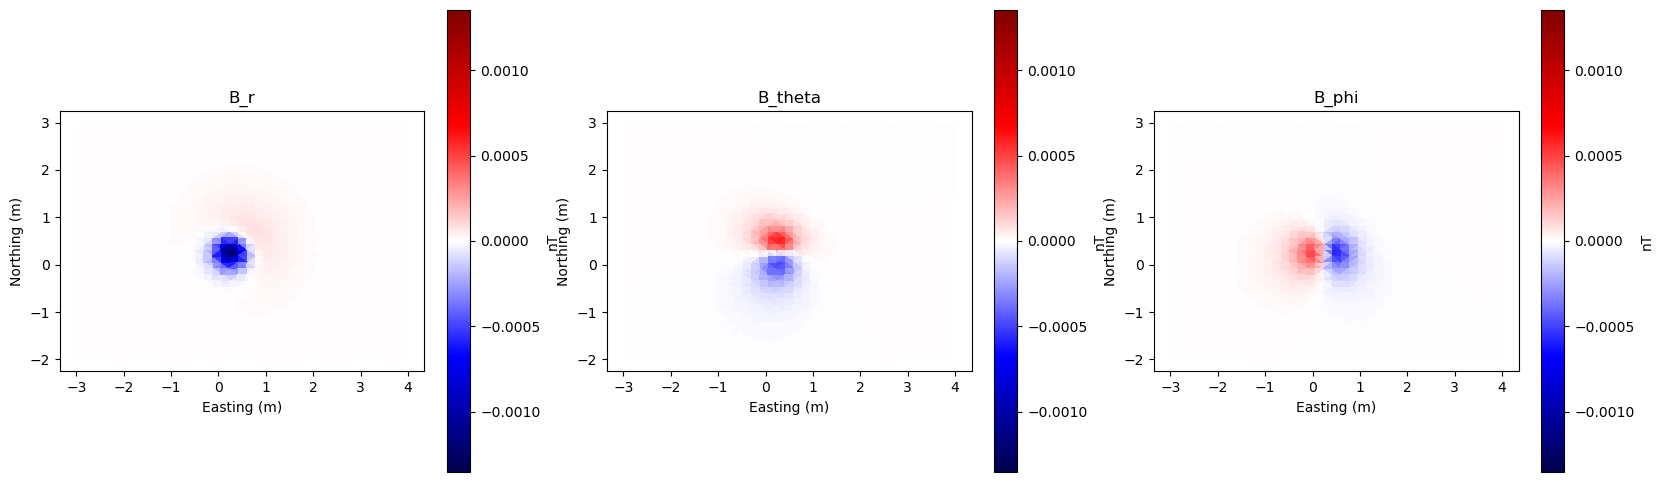

In [20]:
scale = vd.maxabs(B_r)
plt.figure(figsize=(20, 6))
plt.subplot(1,3,1)
plt.tripcolor(longitude, sph_latitude, B_r, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.title('B_r')
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.axis("scaled")

plt.subplot(1,3,2)
plt.tripcolor(longitude, sph_latitude, B_theta, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.title('B_theta')
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.axis("scaled")

plt.subplot(1,3,3)
plt.tripcolor(longitude, sph_latitude,B_newphi, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.title('B_phi')
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.axis("scaled")

plt.show()

In [21]:
def spherical_to_cartesian(r, theta, phi):
    """
    Converte coordenadas esféricas para coordenadas cartesianas.

    Parâmetros:
    r (float): Raio (distância do ponto à origem).
    theta (float): Ângulo da colatitude (em radianos, 0 ≤ θ ≤ π).
    phi (float): Ângulo azimutal (em radianos, 0 ≤ φ < 2π).

    Retorna:
    (x, y, z): Coordenadas cartesianas.
    """
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)
    
    return x, y, z

source_cartesian = spherical_to_cartesian(radius_source, colatitude_source, longitude_source)
obs_cartesian = np.empty((3, n))

for i in range(n):
    obs_cartesian[:,i] = spherical_to_cartesian(radius_obs[i], colatitude_obs[i], longitude_obs[i])

In [22]:
def create_w_matrix(colat, long):

    w11 = np.cos(colat) * np.cos(np.pi-long)
    w12 = - np.cos(colat) * np.sin(np.pi-long)
    w13 = np.sin(colat) 
    
    w21 = -np.sin(np.pi-long)
    w22 = -np.cos(np.pi-long)
    w23 = 0
    
    w31 = -np.sin(colat) * np.cos(np.pi-long)
    w32 = np.sin(colat) * np.sin(np.pi-long)
    w33 = np.cos(colat)
    
    # Construct the matrix
    w = np.array([[w11, w12, w13],
                  [w21, w22, w23],
                  [w31, w32, w33]])
    
    return w

In [23]:
mag_moment_vector = np.array([-m_jtheta, m_jphi, m_jr])
rotated_mag_moment = np.linalg.inv(create_w_matrix(colatitude_source, longitude_source)) @ mag_moment_vector 
b_e, b_n, b_u = hm.dipole_magnetic(obs_cartesian, source_cartesian, rotated_mag_moment, field="b")

print(rotated_mag_moment)

[-8.53770044e+08  2.71496604e+08  2.71504109e+08]


(np.float64(-3.35), np.float64(4.35), np.float64(-2.25), np.float64(3.25))

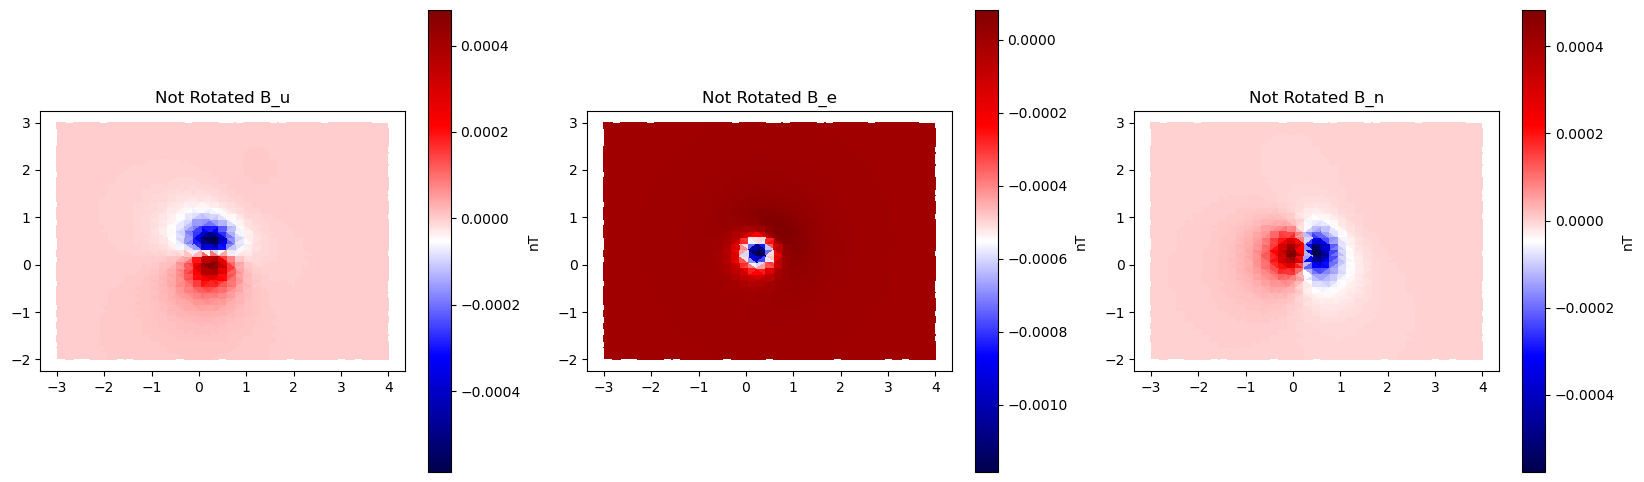

In [24]:
plt.figure(figsize=(20, 6)) 

plt.subplot(1, 3, 1)
plt.tripcolor(longitude, sph_latitude, b_u, cmap="seismic")
plt.colorbar(label='nT')
plt.title('Not Rotated B_u')
plt.axis("scaled")

plt.subplot(1, 3, 2)
plt.tripcolor(longitude, sph_latitude, b_e, cmap="seismic")
plt.colorbar(label='nT')
plt.title("Not Rotated B_e")
plt.axis("scaled")

plt.subplot(1, 3, 3)
plt.tripcolor(longitude, sph_latitude, b_n, cmap="seismic")
plt.colorbar(label='nT')
plt.title('Not Rotated B_n')
plt.axis("scaled")

In [25]:
b_field_vector = np.array([b_e, b_n, b_u]) 
rotated_b_field_vector = np.zeros_like(b_field_vector) 

for i in range(n): 
    rotated_b_field_vector[:, i] = create_w_matrix(colatitude_source, longitude_source) @ b_field_vector[:, i]

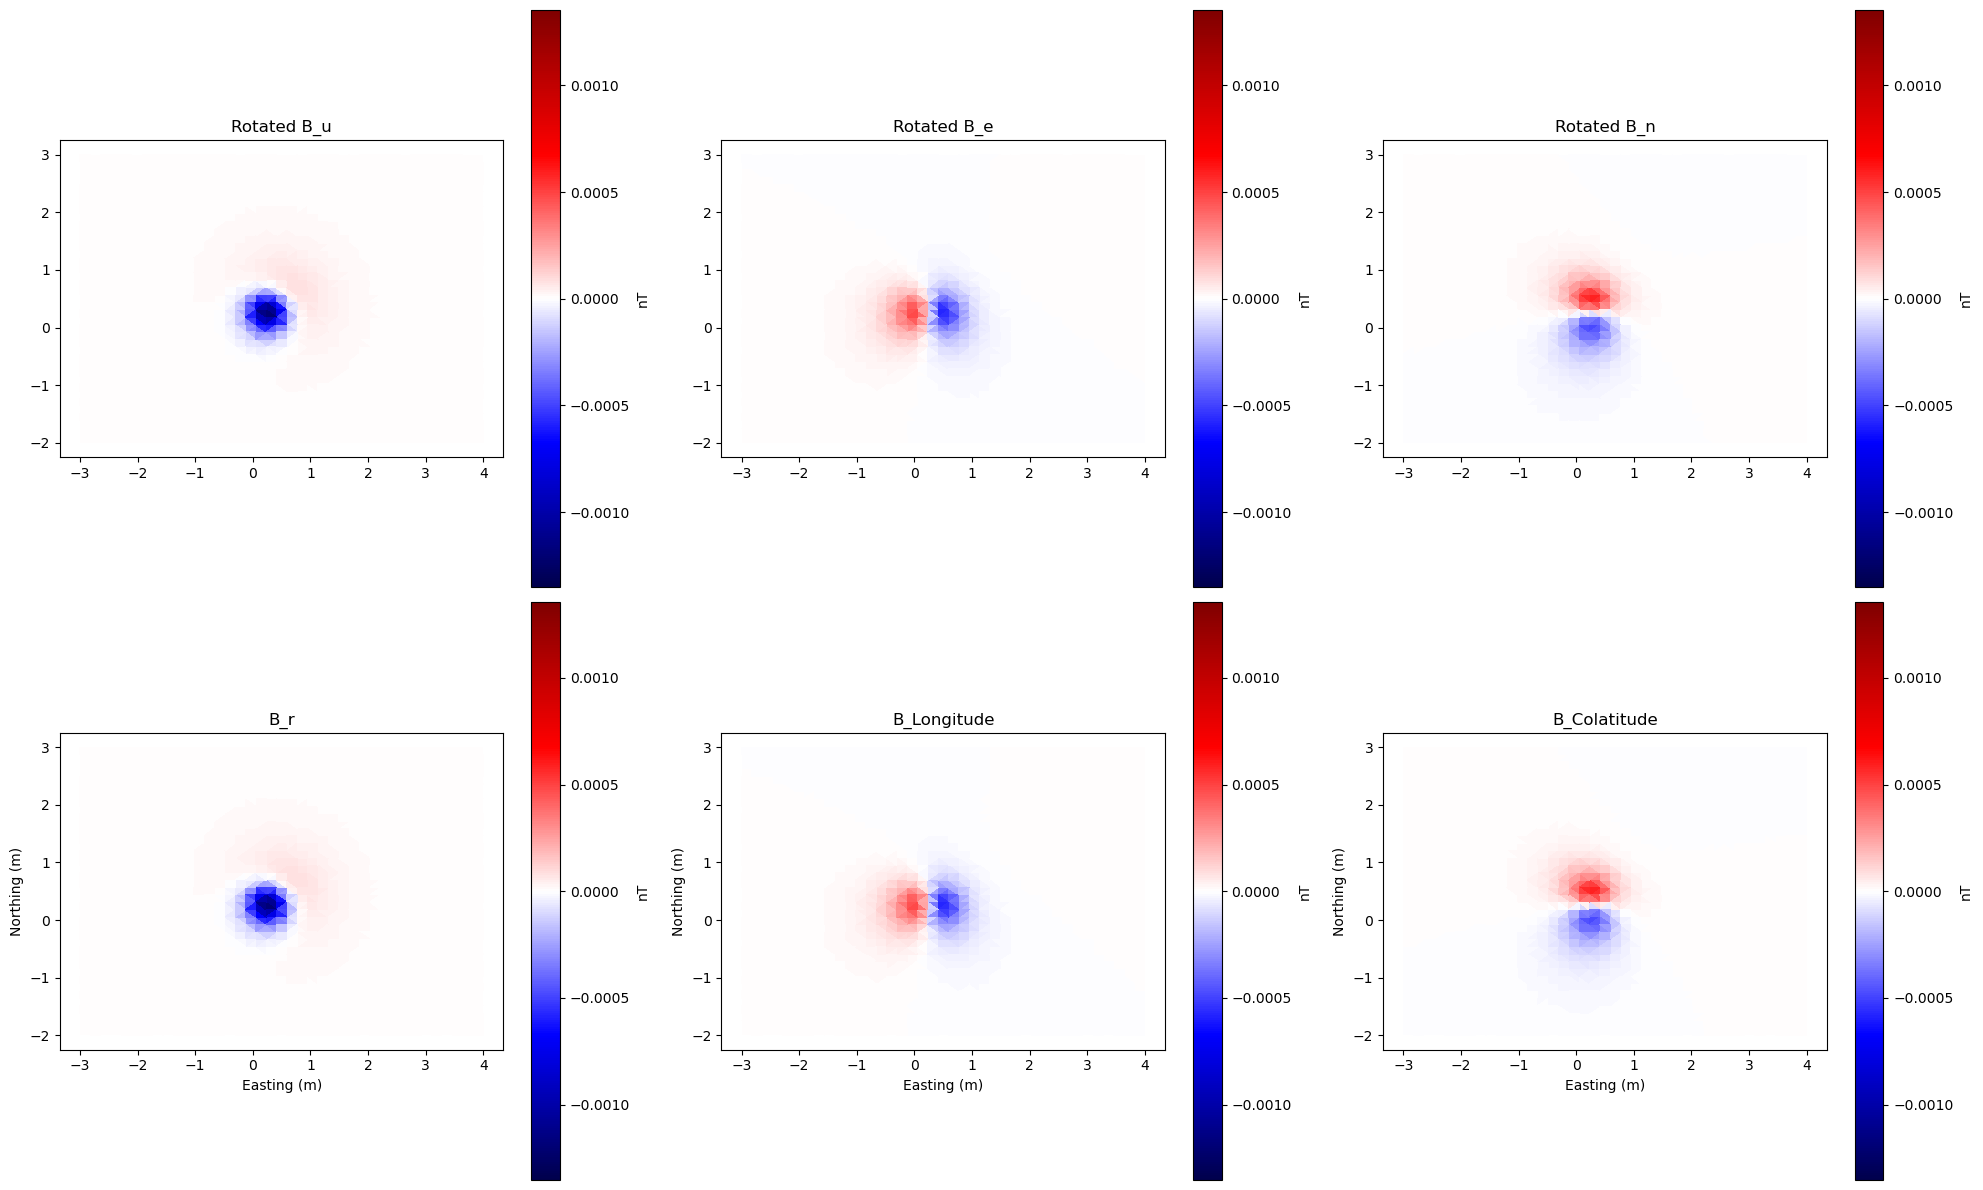

In [26]:
plt.figure(figsize=(20, 12)) 

plt.subplot(2, 3, 1)
plt.tripcolor(longitude, sph_latitude, rotated_b_field_vector[2], cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.title('Rotated B_u')
plt.axis("scaled")

plt.subplot(2, 3, 2)
plt.tripcolor(longitude, sph_latitude, rotated_b_field_vector[1], cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.title("Rotated B_e")
plt.axis("scaled")


plt.subplot(2, 3, 3)
plt.tripcolor(longitude, sph_latitude, -rotated_b_field_vector[0], cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.title('Rotated B_n')
plt.axis("scaled")

plt.subplot(2, 3, 4)
plt.tripcolor(longitude, sph_latitude, B_r, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.title('B_r')
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.axis("scaled")

plt.subplot(2, 3, 5)
plt.tripcolor(longitude, sph_latitude, B_newphi, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.title('B_Longitude')
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.axis("scaled")

plt.subplot(2, 3, 6)
plt.tripcolor(longitude, sph_latitude, B_theta, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.title('B_Colatitude')
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.axis("scaled")

plt.tight_layout()
plt.show()